# Tohoku Mesh: Regions, Extents and Resolution

The mesh used by `notebook_tohoku_open_elevation.ipynb` and
`calibrate_deterministic.py`, examined on its own, without running a
simulation:

1. the lat/lon extent of the model domain, of each refinement polygon, and of
   the two map boxes (the study area and the Sendai plain);
2. how many triangles fall in each refinement region, and what cell size that
   works out to;
3. the mesh itself over the study area and the Sendai plain, with the
   coastline drawn over it.

All the geometry comes from `project.py`, so changing `rfact` or a polygon
there and re-running this notebook shows the effect before paying for a run.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.path import Path
from matplotlib.tri import Triangulation
from pyproj import Transformer
import anuga

%matplotlib inline

try:
    os.chdir('Tohoku')
except OSError:
    pass
print(f'Working directory: {os.getcwd()}')

Working directory: /home/steve/Projects/Tohoku


In [2]:
import project

UTM54 = ccrs.UTM(zone=54)
PC    = ccrs.PlateCarree()
to_ll  = Transformer.from_crs('EPSG:32654', 'EPSG:4326', always_xy=True)
to_utm = Transformer.from_crs('EPSG:4326', 'EPSG:32654', always_xy=True)

Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 15000000                 88753.41           5916
Interior 3600000                  30241.19           8400
Interior 60000                    11288.13           188135
Bounding 15000000                 371317.27          24754
Estimated total number of triangles: 324581
Number of triangles: 324581
output directory: /home/steve/Projects/Tohoku/_output_Caltech
source directory: /home/steve/Projects/Tohoku/sources/Caltech.pts
Note: This is generally about 20% less than the final amount


## Build the mesh

Exactly the call the simulation notebook makes, so the triangle counts below
are the ones a run actually gets.  Nothing is evolved and no GPU is needed.

In [3]:
domain = anuga.create_domain_from_regions(
    project.bounding_polygon,
    boundary_tags={'bottom': [0], 'ocean_east': [1], 'top': [2], 'onshore': [3]},
    maximum_triangle_area=project.res_whole,
    interior_regions=project.interior_regions,
    use_cache=False,
    verbose=False,
)
domain.set_epsg(32654)

xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner

nodes     = domain.nodes + [xll, yll]              # absolute UTM 54N
triangles = domain.triangles
cx = domain.centroid_coordinates[:, 0] + xll
cy = domain.centroid_coordinates[:, 1] + yll
areas = domain.areas

print(f'rfact     : {project.rfact}')
print(f'triangles : {len(domain):,}')
print(f'nodes     : {len(nodes):,}')

rfact     : 30
triangles : 354,946
nodes     : 177,746


## Extents in latitude and longitude

The polygons in `polygons/*.csv` and the old map boxes are all in UTM Zone 54N
metres.  A UTM rectangle is not a lat/lon rectangle -- its edges are neither
meridians nor parallels -- so the table gives the lat/lon *bounding box* of
each shape, computed from its outline densified to 200 points per edge so the
curvature of the edges is included.

The map boxes are now defined in degrees in `project.py`
(`study_extent_ll`, `sendai_extent_ll`), rounded from the bounds of the old
UTM boxes.  Both versions are shown.

In [4]:
def densify(poly, n=200):
    """Closed outline of a polygon, n points per edge."""
    poly = np.asarray(poly, dtype=float)
    ring = np.vstack([poly, poly[:1]])
    pts = [np.linspace(a, b, n, endpoint=False) for a, b in zip(ring[:-1], ring[1:])]
    return np.vstack(pts + [ring[:1]])


def utm_rect(extent):
    xmin, xmax, ymin, ymax = extent
    return [[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]]


def ll_rect(extent):
    lo0, lo1, la0, la1 = extent
    return [[lo0, la0], [lo1, la0], [lo1, la1], [lo0, la1]]


def ll_bounds(poly_utm):
    p = densify(poly_utm)
    lon, lat = to_ll.transform(p[:, 0], p[:, 1])
    return lon.min(), lon.max(), lat.min(), lat.max()


old_study_utm  = [475_000, 580_000, 4_150_000, 4_280_000]
old_sendai_utm = [484_000, 531_500, 4_209_000, 4_252_500]

shapes = {
    'model domain (bounding_extended)': project.bounding_polygon,
    'level 1 (polygon_new1)':           project.poly_level1,
    'level 2 (bounding_gps)':           project.poly_level2,
    'level 3 (bounding_inundation)':    project.poly_level3,
    'study area, old UTM box':          utm_rect(old_study_utm),
    'Sendai plain, old UTM box':        utm_rect(old_sendai_utm),
}

print(f'{"":36s}{"lon min":>9}{"lon max":>9}{"lat min":>9}{"lat max":>9}')
print('-' * 72)
for name, poly in shapes.items():
    print(f'{name:36s}' + ''.join(f'{v:9.3f}' for v in ll_bounds(poly)))
print('-' * 72)
for name, ext in [('study area, project.study_extent_ll', project.study_extent_ll),
                  ('Sendai plain, project.sendai_extent_ll', project.sendai_extent_ll)]:
    print(f'{name:36s}' + ''.join(f'{v:9.3f}' for v in ext))

                                      lon min  lon max  lat min  lat max
------------------------------------------------------------------------
model domain (bounding_extended)      140.051  150.427   35.372   40.831
level 1 (polygon_new1)                140.547  143.310   36.722   40.542
level 2 (bounding_gps)                140.716  142.623   36.837   39.993
level 3 (bounding_inundation)         140.770  142.169   37.323   39.812
study area, old UTM box               140.713  141.920   37.493   38.669
Sendai plain, old UTM box             140.817  141.361   38.028   38.421
------------------------------------------------------------------------
study area, project.study_extent_ll   140.700  141.900   37.500   38.650
Sendai plain, project.sendai_extent_ll  140.820  141.360   38.030   38.420


Corner coordinates of the two map boxes, for quoting in a report.  The
east edge of the old UTM study box runs from 141.905 E at its south end to
141.920 E at its north end: that 0.015 deg lean is the angle between UTM
north and true north, which grows with distance from the zone's central
meridian at 141 E.

In [5]:
for name, ext in [('study area', old_study_utm), ('Sendai plain', old_sendai_utm)]:
    print(f'{name} (old UTM box) corners, lon/lat:')
    for label, (x, y) in zip(['SW', 'SE', 'NE', 'NW'], utm_rect(ext)):
        lon, lat = to_ll.transform(x, y)
        print(f'   {label}  {lon:8.4f} E  {lat:7.4f} N    ({x:,.0f} E, {y:,.0f} N)')

study area (old UTM box) corners, lon/lat:
   SW  140.7172 E  37.4966 N    (475,000 E, 4,150,000 N)
   SE  141.9050 E  37.4935 N    (580,000 E, 4,150,000 N)
   NE  141.9195 E  38.6650 N    (580,000 E, 4,280,000 N)
   NW  140.7126 E  38.6682 N    (475,000 E, 4,280,000 N)
Sendai plain (old UTM box) corners, lon/lat:
   SW  140.8177 E  38.0286 N    (484,000 E, 4,209,000 N)
   SE  141.3589 E  38.0282 N    (531,500 E, 4,209,000 N)
   NE  141.3608 E  38.4202 N    (531,500 E, 4,252,500 N)
   NW  140.8167 E  38.4206 N    (484,000 E, 4,252,500 N)


## Triangles in each refinement region

`project.interior_regions` nests three polygons inside the model domain, each
with its own maximum triangle area.  Each triangle is assigned to the
*innermost* polygon containing its centroid, which is the region whose area
limit governs it.

The equivalent cell size is the side of an equilateral triangle of the mean
area, `sqrt(4 A / sqrt(3))`; `sqrt(A)` would understate it by ~1.5x.

In [6]:
region_polys = [
    ('outside level 1',          None,                project.res_whole),
    ('level 1 (polygon_new1)',   project.poly_level1, project.res_level1),
    ('level 2 (bounding_gps)',   project.poly_level2, project.res_level2),
    ('level 3 (inundation)',     project.poly_level3, project.res_level3),
]

# Check the nesting assumption rather than trusting it.
for (n_out, p_out, _), (n_in, p_in, _) in zip(region_polys[1:], region_polys[2:]):
    inside = Path(p_out).contains_points(np.asarray(p_in)).all()
    print(f'{n_in:26s} inside {n_out:26s}: {inside}')

centroids = np.column_stack([cx, cy])
region = np.zeros(len(domain), dtype=int)
for k, (_, poly, _) in enumerate(region_polys[1:], start=1):
    region[Path(poly).contains_points(centroids)] = k

edge = lambda a: np.sqrt(4.0 * a / np.sqrt(3.0))

print()
print(f'{"region":26s}{"triangles":>11}{"share":>8}{"area km2":>11}'
      f'{"max area km2":>14}{"mean area km2":>15}{"mean edge km":>14}')
print('-' * 99)
for k, (name, _, res) in enumerate(region_polys):
    m = region == k
    a = areas[m]
    print(f'{name:26s}{m.sum():11,d}{m.mean():8.1%}{a.sum() / 1e6:11,.0f}'
          f'{res / 1e6:14.3f}{a.mean() / 1e6:15.3f}{edge(a.mean()) / 1e3:14.2f}')
print('-' * 99)
print(f'{"total":26s}{len(domain):11,d}{1:8.0%}{areas.sum() / 1e6:11,.0f}')

level 2 (bounding_gps)     inside level 1 (polygon_new1)    : True
level 3 (inundation)       inside level 2 (bounding_gps)    : True

region                      triangles   share   area km2  max area km2  mean area km2  mean edge km
---------------------------------------------------------------------------------------------------
outside level 1                42,681   12.0%    412,847        15.000          9.673          4.73
level 1 (polygon_new1)          6,424    1.8%     58,512        15.000          9.108          4.59
level 2 (bounding_gps)         15,070    4.2%     18,953         3.600          1.258          1.70
level 3 (inundation)          290,771   81.9%     11,288         0.060          0.039          0.30
---------------------------------------------------------------------------------------------------
total                         354,946    100%    501,600


Reading it: level 3 holds almost every triangle on a small fraction of the
area.  Its mean edge, ~300 m, is what the rest of the repo loosely calls the
"~250 m mesh".  The outer regions sit well below their area limits because
the mesher grades smoothly into the refined region rather than jumping at
the polygon edge.

## Refinement regions over the model domain

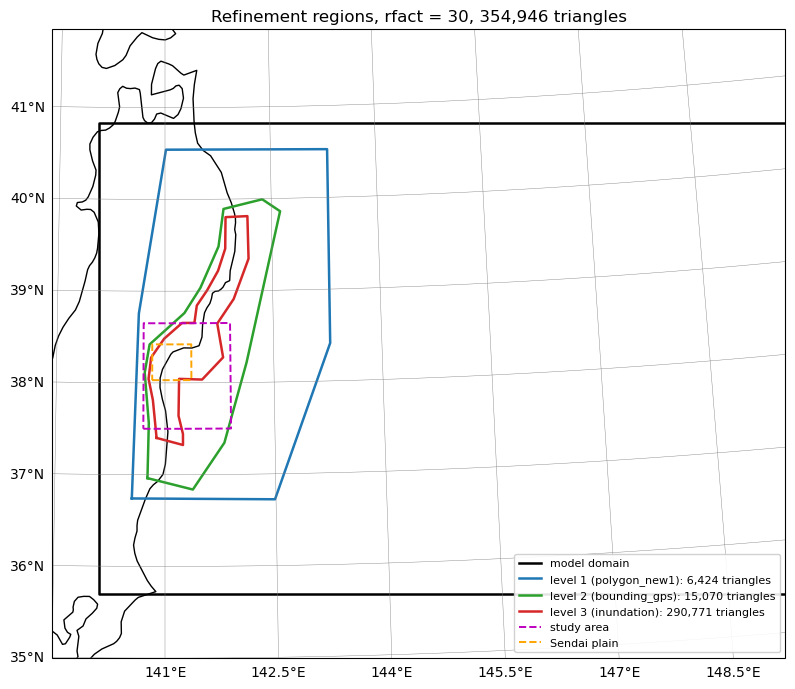

In [7]:
region_colors = ['0.85', 'C0', 'C2', 'C3']

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={'projection': UTM54})

for k, ((name, poly, _), c) in enumerate(zip(region_polys, region_colors)):
    if poly is None:
        poly, c, label = project.bounding_polygon, 'k', 'model domain'
    else:
        label = f'{name}: {np.sum(region == k):,} triangles'
    p = densify(poly, n=20)
    ax.plot(p[:, 0], p[:, 1], color=c, lw=1.8, transform=UTM54, label=label)

for ext, c, label in [(project.study_extent_ll, 'm', 'study area'),
                      (project.sendai_extent_ll, 'orange', 'Sendai plain')]:
    p = densify(ll_rect(ext), n=20)
    ax.plot(p[:, 0], p[:, 1], color=c, lw=1.4, ls='--', transform=PC, label=label)

ax.coastlines(resolution='50m')
ax.set_extent([139.5, 152.0, 35.0, 41.5], crs=PC)
gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray')
gl.top_labels = gl.right_labels = False
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.set_title(f'Refinement regions, rfact = {project.rfact}, {len(domain):,} triangles')
plt.tight_layout()

## The mesh over the study area and the Sendai plain

Two coastlines are drawn over the mesh, and they are worth telling apart:

- **blue** -- Natural Earth at 1:10 m, an independent reference;
- **orange** -- the model's own 0 m contour, from the open DEM
  (`Tohoku_dem.tif`) interpolated onto the mesh centroids.  This is the
  coastline the simulation actually sees.

They agree to within a cell or two along most of the coast, but not on the
Sendai plain: south of Sendai port the model's 0 m line runs up to ~2 km
*landward* of the reference, so the DEM puts a strip of the low plain below
sea level.  That is water the model starts with on land, and worth knowing
before reading the Sendai inundation results.  The level-3 refinement
boundary is in red.

Only the triangles near each box are drawn, so the plots stay quick.  At the
study-area scale the ~300 m level-3 triangles are too dense to resolve and
read as grey; the Sendai panel and the Arahama close-up below show them.

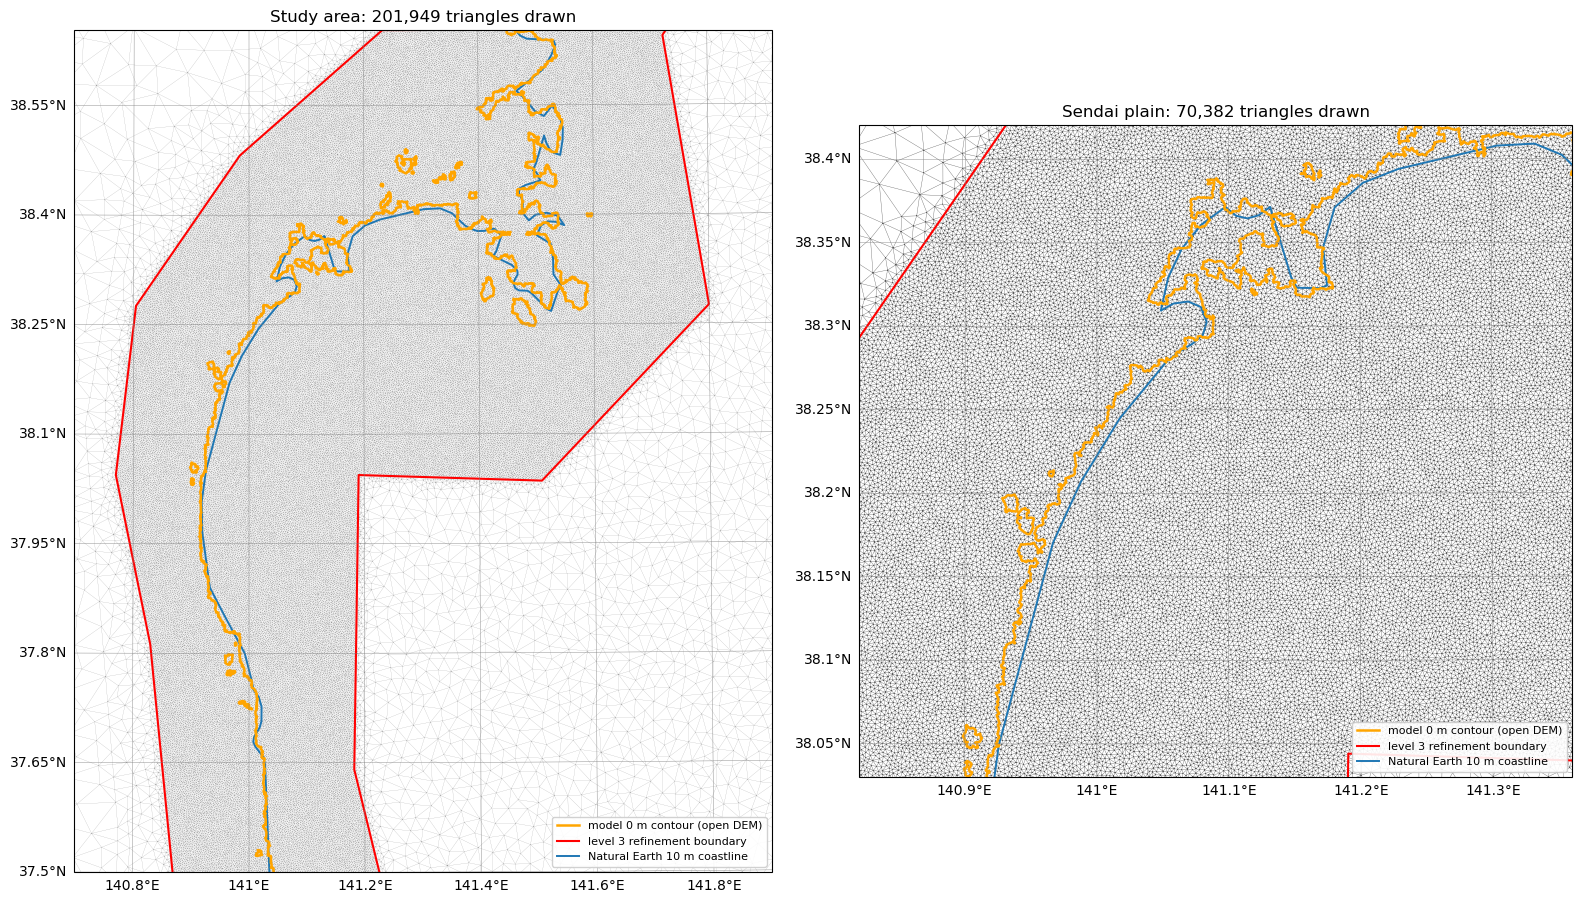

In [8]:
import warnings
warnings.filterwarnings('ignore', message='invalid value encountered in linestrings')

domain.set_quantity('elevation', filename='Tohoku_dem.tif', location='centroids')
elev_c = domain.quantities['elevation'].centroid_values.copy()
cell_lon, cell_lat = to_ll.transform(cx, cy)


def mesh_panel(ax, extent_ll, title, lw):
    # Select triangles by centroid in lat/lon, with a margin so the plot
    # reaches the frame edge.
    pad = 0.1 * max(extent_ll[1] - extent_ll[0], extent_ll[3] - extent_ll[2])
    sel = ((cell_lon > extent_ll[0] - pad) & (cell_lon < extent_ll[1] + pad) &
           (cell_lat > extent_ll[2] - pad) & (cell_lat < extent_ll[3] + pad))

    ax.triplot(Triangulation(nodes[:, 0], nodes[:, 1], triangles[sel]),
               color='0.35', lw=lw, transform=UTM54)

    # Model coastline: 0 m contour of the centroid elevations.
    ax.tricontour(Triangulation(cx[sel], cy[sel]), elev_c[sel], levels=[0.0],
                  colors='orange', linewidths=1.8, transform=UTM54)
    ax.plot([], [], color='orange', lw=1.8, label='model 0 m contour (open DEM)')

    p = densify(project.poly_level3, n=20)
    ax.plot(p[:, 0], p[:, 1], color='r', lw=1.5, transform=UTM54,
            label='level 3 refinement boundary')
    ax.coastlines(resolution='10m', color='C0', lw=1.4)
    ax.plot([], [], color='C0', lw=1.4, label='Natural Earth 10 m coastline')

    ax.set_extent(extent_ll, crs=PC)
    gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray')
    gl.top_labels = gl.right_labels = False
    ax.set_title(f'{title}: {sel.sum():,} triangles drawn')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(1, 2, figsize=(16, 9), subplot_kw={'projection': UTM54})
mesh_panel(axes[0], project.study_extent_ll, 'Study area', lw=0.08)
mesh_panel(axes[1], project.sendai_extent_ll, 'Sendai plain', lw=0.25)
plt.tight_layout()

A close-up at Arahama, where the transect in the simulation notebook crosses
the coast, at a scale where individual triangles can be seen.

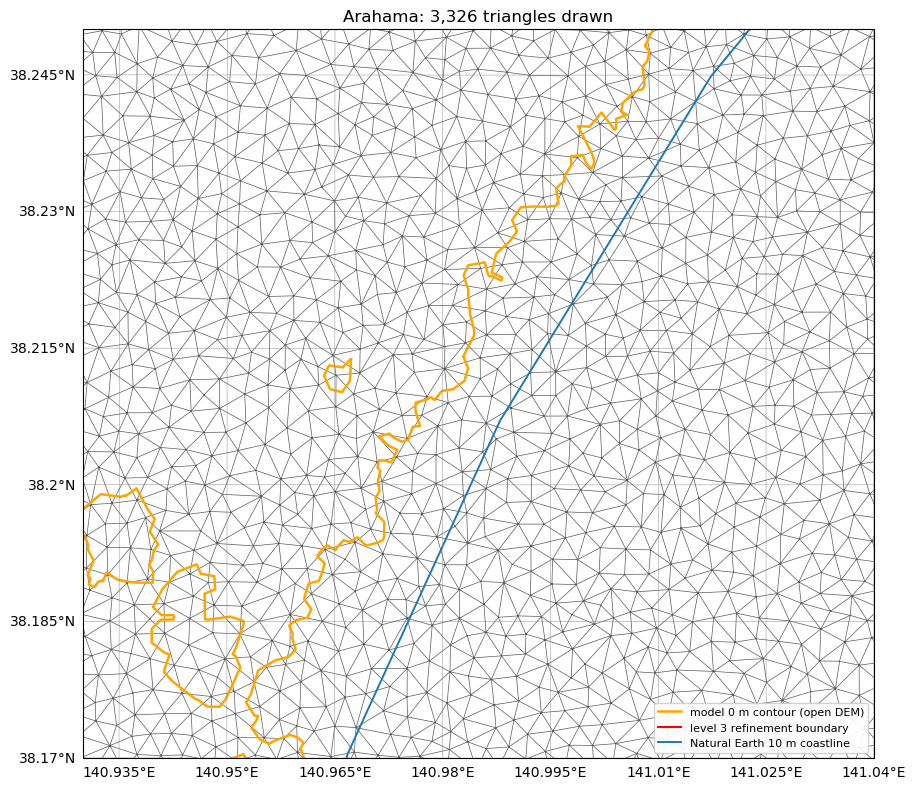

In [9]:
arahama_extent_ll = [140.93, 141.04, 38.17, 38.25]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={'projection': UTM54})
mesh_panel(ax, arahama_extent_ll, 'Arahama', lw=0.5)
plt.tight_layout()